Prédictions : [0 1]


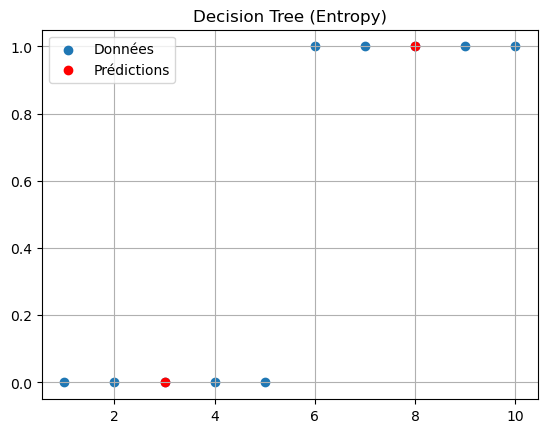

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. DONNÉES
# ==========================================================
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([0,0,0,0,0,1,1,1,1,1])


# ==========================================================
# 2. ENTROPY
# ==========================================================
def entropy(y):
    """
    Calcule l'entropie :
    plus les classes sont mélangées,
    plus l'entropie est grande
    """
    classes = np.unique(y)
    ent = 0

    for c in classes:
        p = np.sum(y == c) / len(y)

        if p > 0:
            ent -= p * np.log2(p)

    return ent


# ==========================================================
# 3. SPLIT
# ==========================================================
def split_dataset(X, y, threshold):

    left_mask = X[:,0] <= threshold
    right_mask = X[:,0] > threshold

    return X[left_mask], X[right_mask], y[left_mask], y[right_mask]


# ==========================================================
# 4. INFORMATION GAIN
# ==========================================================
def information_gain(y, y_left, y_right):

    parent_entropy = entropy(y)

    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)

    # Entropie pondérée enfants
    child_entropy = (n_left/n)*entropy(y_left) + \
                    (n_right/n)*entropy(y_right)

    gain = parent_entropy - child_entropy

    return gain


# ==========================================================
# 5. MEILLEUR SPLIT
# ==========================================================
def best_split(X, y):

    best_gain = -1
    best_threshold = None

    thresholds = np.unique(X)

    for threshold in thresholds:

        _, _, y_left, y_right = split_dataset(X, y, threshold)

        if len(y_left) == 0 or len(y_right) == 0:
            continue

        gain = information_gain(y, y_left, y_right)

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold


# ==========================================================
# 6. NOEUD
# ==========================================================
class Node:
    def __init__(self, threshold=None, left=None, right=None, value=None):
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


# ==========================================================
# 7. CONSTRUCTION ARBRE
# ==========================================================
def build_tree(X, y, depth=0, max_depth=3):

    # Si une seule classe
    if len(np.unique(y)) == 1:
        return Node(value=y[0])

    # profondeur max
    if depth >= max_depth:
        majority = np.bincount(y).argmax()
        return Node(value=majority)

    threshold = best_split(X, y)

    if threshold is None:
        majority = np.bincount(y).argmax()
        return Node(value=majority)

    X_left, X_right, y_left, y_right = split_dataset(X, y, threshold)

    left_subtree = build_tree(X_left, y_left, depth+1, max_depth)
    right_subtree = build_tree(X_right, y_right, depth+1, max_depth)

    return Node(threshold, left_subtree, right_subtree)


# ==========================================================
# 8. PRÉDICTION
# ==========================================================
def predict_one(x, tree):

    if tree.value is not None:
        return tree.value

    if x[0] <= tree.threshold:
        return predict_one(x, tree.left)
    else:
        return predict_one(x, tree.right)


def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])


# ==========================================================
# 9. ENTRAÎNEMENT
# ==========================================================
tree = build_tree(X, y)


# ==========================================================
# 10. TEST
# ==========================================================
X_test = np.array([[3],[8]])
preds = predict(X_test, tree)

print("Prédictions :", preds)


# ==========================================================
# 11. VISUALISATION
# ==========================================================
plt.scatter(X, y, label="Données")
plt.scatter(X_test, preds, color='red', label="Prédictions")
plt.title("Decision Tree (Entropy)")
plt.legend()
plt.grid()
plt.show()